# Lorenz63 Neural ODE Training Cookbook

This notebook trains a Lorenz63 Neural ODE model and evaluates learning curves for both in-sample training data and out-of-sample testing data.

In [37]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.optim import AdamW

repo_root = Path.cwd()
if repo_root.name == "examples":
    repo_root = repo_root.parent

src_path = repo_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from lorenz63_neuralode.data import get_dataloaders
from lorenz63_neuralode.models import build_lorenz63_model

torch.manual_seed(42)
plt.rcParams.update({"figure.dpi": 120})

repo_root

PosixPath('/srv/data/kezhoulumelody/Lorenz63_NeuralODE')

## Configuration

Change `MODEL_NAME` to specific models: `residual_mlp`, `polynomial`, `bilinear`, `attention`, `graph`, and `transformer`.

In [38]:
MODEL_NAME = "residual_mix"

DATA_PATH = repo_root / "data" / "lorenz63_trajectory_10-28-2.7.npz"
OUTPUT_DIR = repo_root / "outputs" / f"lorenz63_{MODEL_NAME}"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SIGMA_INIT = 1
RHO_INIT = 1
BETA_INIT = 2
# hidden dimensions are only used in residual_MLP, residual_MIX, pure_MP, transformer and attention models
HIDDEN_DIM = 64
# hidden layers will only be used in residual_MLP, residual_MIX, pure_MLP models
N_HIDDEN_LAYERS = 2

BATCH_SIZE = 256
N_EPOCHS = 180
LR = 1e-3
WEIGHT_DECAY = 1e-3
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

SAVE_ARTIFACTS = True
CHECKPOINT_PATH = OUTPUT_DIR / f"lorenz63_{MODEL_NAME}_10-28-2.7_1-1-2.pt"
CURVE_PATH = OUTPUT_DIR / f"lorenz63_{MODEL_NAME}_cookbook_curves.png"

print(f"device: {DEVICE}")
print(f"data: {DATA_PATH}")

device: cuda
data: /srv/data/kezhoulumelody/Lorenz63_NeuralODE/data/lorenz63_trajectory_10-28-2.7.npz


## Load Data And Build Model

In [39]:
train_loader, test_loader = get_dataloaders(
    npz_path=DATA_PATH,
    batch_size=BATCH_SIZE,
)

model = build_lorenz63_model(
    model_name=MODEL_NAME,
    sigma_init=SIGMA_INIT,
    rho_init=RHO_INIT,
    beta_init=BETA_INIT,
    hidden_dim=HIDDEN_DIM,
    n_hidden_layers=N_HIDDEN_LAYERS,
).to(DEVICE)

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
loss_fn = nn.MSELoss()

n_train = len(train_loader.dataset)
n_test = len(test_loader.dataset)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(model)
print(f"train samples: {n_train}, test samples: {n_test}")
print(f"trainable parameters: {n_params}")

Lorenz63ResidualMixModel(
  (linear): StructuredLorenz63Linear()
  (residual_net): ResidualMLP(
    (net): Sequential(
      (0): Linear(in_features=3, out_features=64, bias=True)
      (1): Tanh()
      (2): Linear(in_features=64, out_features=64, bias=True)
      (3): Tanh()
      (4): Linear(in_features=64, out_features=3, bias=True)
    )
  )
)
train samples: 80000, test samples: 20000
trainable parameters: 4614


## Metric Helpers

`evaluate_split` returns overall RMSE, component-wise RMSE for `dx/dt`, `dy/dt`, and `dz/dt`, plus overall and component-wise ACC.

In [40]:
@torch.no_grad()
def evaluate_split(model, dataloader, device):
    model.eval()
    preds = []
    targets = []

    for batch in dataloader:
        state = batch["state"].to(device)
        target = batch["dxdt"].to(device)
        pred = model(state)
        preds.append(pred.detach().cpu())
        targets.append(target.detach().cpu())

    pred = torch.cat(preds, dim=0)
    target = torch.cat(targets, dim=0)
    err = pred - target

    eps = 1e-12
    rmse = torch.sqrt(torch.mean(err ** 2))
    component_rmse = torch.sqrt(torch.mean(err ** 2, dim=0))

    target_mean = torch.mean(target, dim=0, keepdim=True)
    pred_anom = pred - target_mean
    target_anom = target - target_mean

    acc_numerator = torch.sum(pred_anom * target_anom)
    acc_denominator = torch.sqrt(torch.sum(pred_anom ** 2) * torch.sum(target_anom ** 2)).clamp_min(eps)
    acc = acc_numerator / acc_denominator

    component_acc_numerator = torch.sum(pred_anom * target_anom, dim=0)
    component_acc_denominator = torch.sqrt(
        torch.sum(pred_anom ** 2, dim=0) * torch.sum(target_anom ** 2, dim=0)
    ).clamp_min(eps)
    component_acc = component_acc_numerator / component_acc_denominator

    return {
        "rmse": float(rmse),
        "component_rmse": [float(v) for v in component_rmse],
        "acc": float(acc),
        "component_acc": [float(v) for v in component_acc],
    }


def append_metrics(history, prefix, metrics):
    history[f"{prefix}_rmse"].append(metrics["rmse"])
    history[f"{prefix}_component_rmse"].append(metrics["component_rmse"])
    history[f"{prefix}_acc"].append(metrics["acc"])
    history[f"{prefix}_component_acc"].append(metrics["component_acc"])

## Train

The training loop evaluates the model on both splits after each epoch, so the curves below show in-sample and out-of-sample behavior over training.

In [ ]:
history = {
    "epoch": [],
    "train_loss": [],
    "train_rmse": [],
    "test_rmse": [],
    "train_component_rmse": [],
    "test_component_rmse": [],
    "train_acc": [],
    "test_acc": [],
    "train_component_acc": [],
    "test_component_acc": [],
}

for epoch in range(1, N_EPOCHS + 1):
    model.train()
    total_loss = 0.0
    n_samples = 0

    for batch in train_loader:
        state = batch["state"].to(DEVICE)
        target = batch["dxdt"].to(DEVICE)

        pred = model(state)
        loss = loss_fn(pred, target)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        batch_n = state.shape[0]
        total_loss += loss.item() * batch_n
        n_samples += batch_n

    train_loss = total_loss / max(n_samples, 1)
    train_metrics = evaluate_split(model, train_loader, DEVICE)
    test_metrics = evaluate_split(model, test_loader, DEVICE)

    history["epoch"].append(epoch)
    history["train_loss"].append(float(train_loss))
    append_metrics(history, "train", train_metrics)
    append_metrics(history, "test", test_metrics)

    if epoch == 1 or epoch % 10 == 0 or epoch == N_EPOCHS:
        print(
            f"epoch {epoch:04d} | "
            f"loss {train_loss:.6f} | "
            f"train RMSE {train_metrics['rmse']:.6f} | "
            f"test RMSE {test_metrics['rmse']:.6f} | "
            f"train ACC {train_metrics['acc']:.4f} | "
            f"test ACC {test_metrics['acc']:.4f}"
        )

epoch 0001 | loss 4848.036466 | train RMSE 68.347969 | test RMSE 68.137177 | train ACC 0.0299 | test ACC 0.0307
epoch 0010 | loss 2892.464928 | train RMSE 53.203114 | test RMSE 53.100712 | train ACC 0.7263 | test ACC 0.7202
epoch 0020 | loss 1999.705723 | train RMSE 44.323036 | test RMSE 44.267071 | train ACC 0.8229 | test ACC 0.8199
epoch 0030 | loss 1415.438180 | train RMSE 37.301277 | test RMSE 37.251835 | train ACC 0.8695 | test ACC 0.8679
epoch 0040 | loss 1007.723593 | train RMSE 31.470154 | test RMSE 31.423866 | train ACC 0.9046 | test ACC 0.9037
epoch 0050 | loss 711.486833 | train RMSE 26.438513 | test RMSE 26.398046 | train ACC 0.9334 | test ACC 0.9328
epoch 0060 | loss 499.787757 | train RMSE 22.155897 | test RMSE 22.130327 | train ACC 0.9523 | test ACC 0.9518
epoch 0070 | loss 349.313346 | train RMSE 18.521002 | test RMSE 18.516861 | train ACC 0.9659 | test ACC 0.9655
epoch 0080 | loss 242.697661 | train RMSE 15.435472 | test RMSE 15.450542 | train ACC 0.9759 | test ACC 0.9

## Learning Curves

saved curves to /srv/data/kezhoulumelody/Lorenz63_NeuralODE/outputs/lorenz63_residual_mix/lorenz63_residual_mix_cookbook_curves.png


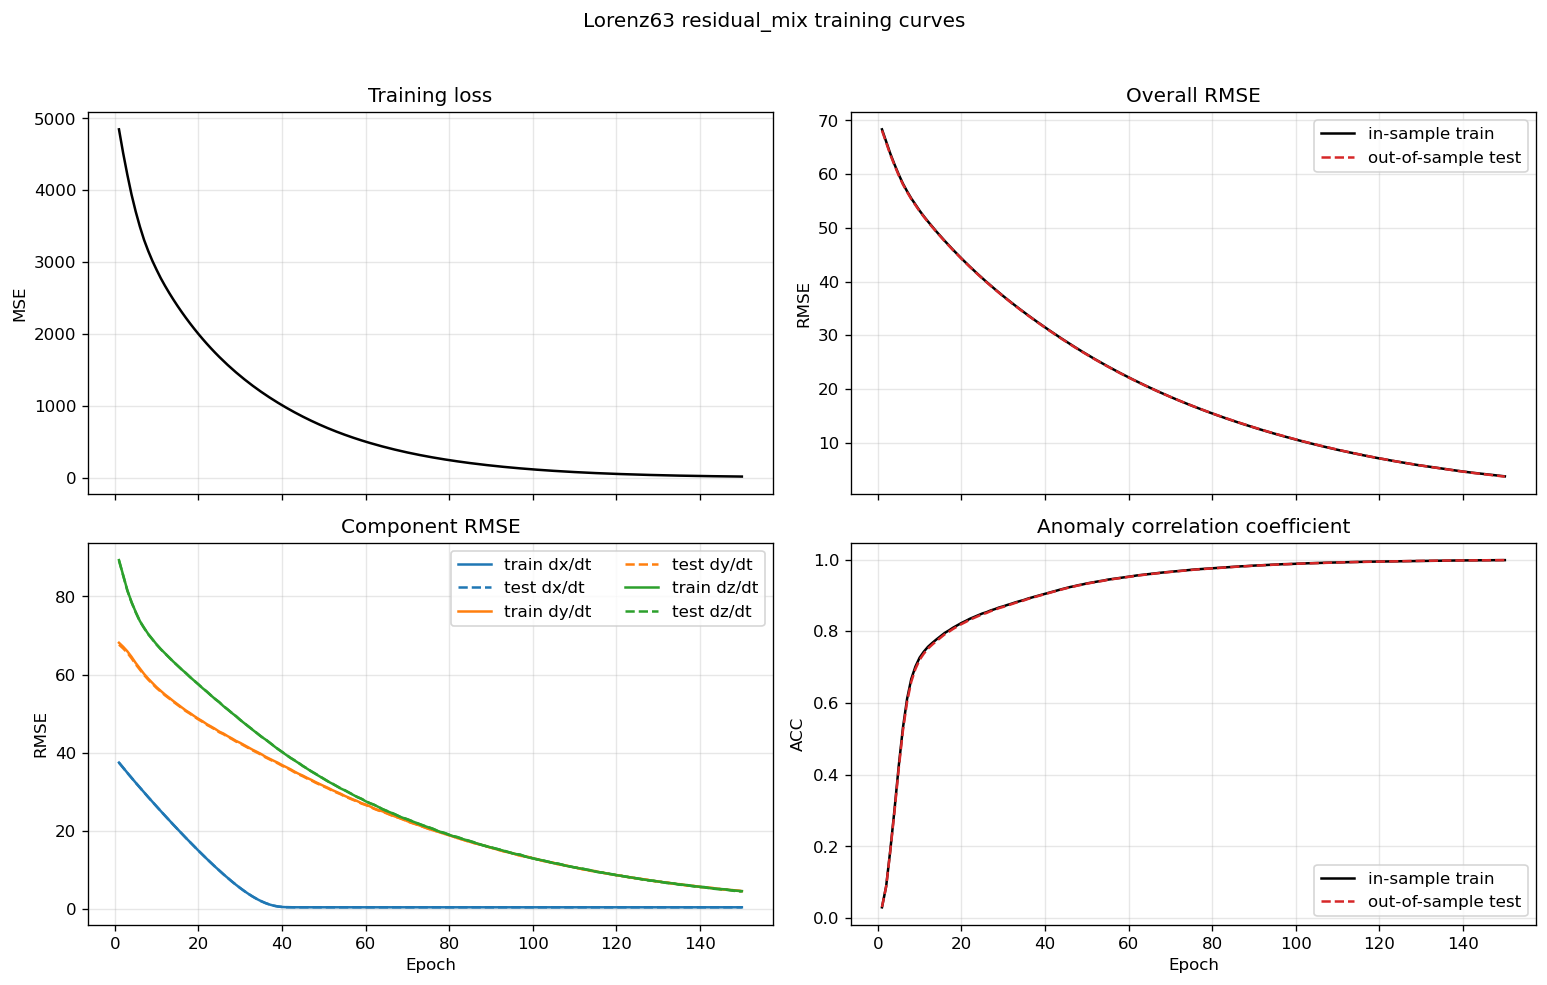

In [ ]:
epochs = history["epoch"]
component_names = ["dx/dt", "dy/dt", "dz/dt"]
component_colors = ["tab:blue", "tab:orange", "tab:green"]

train_component_rmse = torch.tensor(history["train_component_rmse"])
test_component_rmse = torch.tensor(history["test_component_rmse"])
train_component_acc = torch.tensor(history["train_component_acc"])
test_component_acc = torch.tensor(history["test_component_acc"])

fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True)

axes[0, 0].plot(epochs, history["train_loss"], color="black")
axes[0, 0].set_title("Training loss")
axes[0, 0].set_ylabel("MSE")
axes[0, 0].grid(alpha=0.3)

axes[0, 1].plot(epochs, history["train_rmse"], label="in-sample train", color="black")
axes[0, 1].plot(epochs, history["test_rmse"], label="out-of-sample test", color="tab:red", linestyle="--")
axes[0, 1].set_title("Overall RMSE")
axes[0, 1].set_ylabel("RMSE")
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

for idx, (name, color) in enumerate(zip(component_names, component_colors)):
    axes[1, 0].plot(epochs, train_component_rmse[:, idx], label=f"train {name}", color=color)
    axes[1, 0].plot(epochs, test_component_rmse[:, idx], label=f"test {name}", color=color, linestyle="--")
axes[1, 0].set_title("Component RMSE")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("RMSE")
axes[1, 0].legend(ncol=2)
axes[1, 0].grid(alpha=0.3)

axes[1, 1].plot(epochs, history["train_acc"], label="in-sample train", color="black")
axes[1, 1].plot(epochs, history["test_acc"], label="out-of-sample test", color="tab:red", linestyle="--")
axes[1, 1].set_title("Anomaly correlation coefficient")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].set_ylabel("ACC")
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

fig.suptitle(f"Lorenz63 {MODEL_NAME} training curves", y=1.02)
fig.tight_layout()

if SAVE_ARTIFACTS:
    fig.savefig(CURVE_PATH, dpi=200, bbox_inches="tight")
    print(f"saved curves to {CURVE_PATH}")

plt.show()

## Component ACC Curves

These show anomaly correlation coefficient separately for the three derivative components.

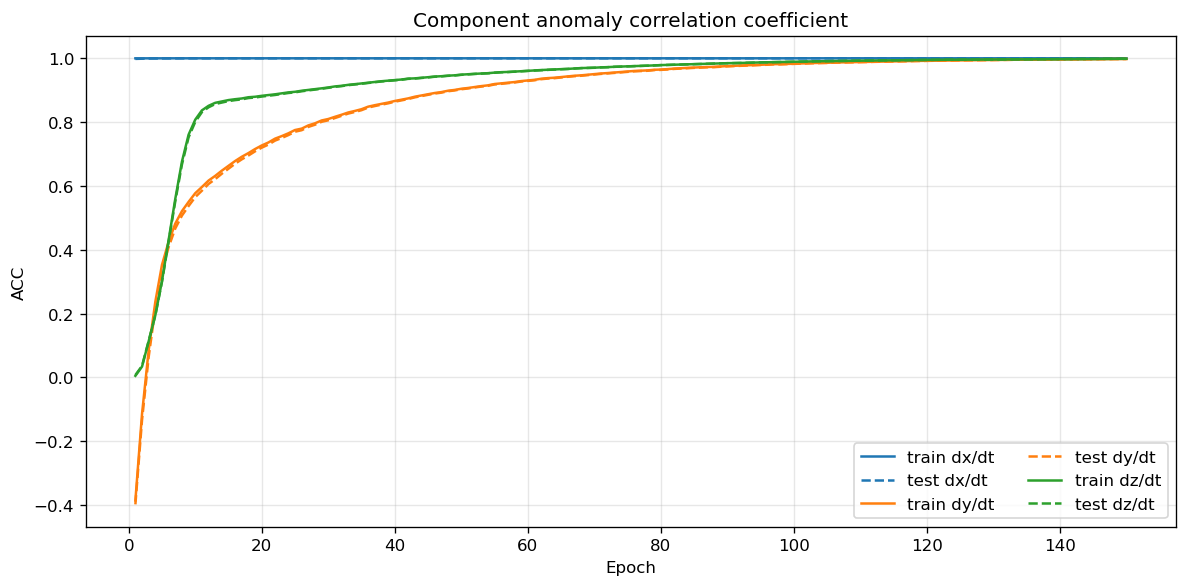

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

for idx, (name, color) in enumerate(zip(component_names, component_colors)):
    ax.plot(epochs, train_component_acc[:, idx], label=f"train {name}", color=color)
    ax.plot(epochs, test_component_acc[:, idx], label=f"test {name}", color=color, linestyle="--")

ax.set_title("Component anomaly correlation coefficient")
ax.set_xlabel("Epoch")
ax.set_ylabel("ACC")
ax.legend(ncol=2)
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## Final Metrics

In [ ]:
final = {
    "train_rmse": history["train_rmse"][-1],
    "test_rmse": history["test_rmse"][-1],
    "train_acc": history["train_acc"][-1],
    "test_acc": history["test_acc"][-1],
    "train_component_rmse": dict(zip(component_names, history["train_component_rmse"][-1])),
    "test_component_rmse": dict(zip(component_names, history["test_component_rmse"][-1])),
}

final

{'train_rmse': 3.723012685775757,
 'test_rmse': 3.682706117630005,
 'train_acc': 0.9984295964241028,
 'test_acc': 0.9984567761421204,
 'train_component_rmse': {'dx/dt': 0.4121301770210266,
  'dy/dt': 4.544087886810303,
  'dz/dt': 4.556740760803223},
 'test_component_rmse': {'dx/dt': 0.4094436764717102,
  'dy/dt': 4.5347723960876465,
  'dz/dt': 4.467121124267578}}

## Save Checkpoint

In [ ]:
if SAVE_ARTIFACTS:
    checkpoint_params = {
        "model_name": MODEL_NAME,
        "sigma_init": SIGMA_INIT,
        "rho_init": RHO_INIT,
        "beta_init": BETA_INIT,
        "hidden_dim": HIDDEN_DIM,
        "n_hidden_layers": N_HIDDEN_LAYERS,
        "learned_A": model.A.detach().cpu() if hasattr(model, "A") else None,
    }

    torch.save(
        {
            "model_state_dict": model.state_dict(),
            "history": history,
            "params": checkpoint_params,
        },
        CHECKPOINT_PATH,
    )
    print(f"saved checkpoint to {CHECKPOINT_PATH}")
    print("saved params:")
    print(checkpoint_params)

saved checkpoint to /srv/data/kezhoulumelody/Lorenz63_NeuralODE/outputs/lorenz63_residual_mix/lorenz63_residual_mix_10-28-2.7_1-1-2.pt
saved params:
{'model_name': 'residual_mix', 'sigma_init': 1, 'rho_init': 1, 'beta_init': 2, 'hidden_dim': 64, 'n_hidden_layers': 2, 'learned_A': tensor([[-9.9755,  9.9755,  0.0000],
        [-3.3057, -1.0000,  0.0000],
        [ 0.0000,  0.0000,  1.9071]])}
